# 12. Core Findings Summary

This notebook turns the main historical analysis outputs into a concise, report-ready summary. It focuses on interpretation and communication rather than generating new exploratory metrics.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [2]:
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

from config import COLLAPSE_DATASET_PATH
from dataset_utils import get_factor_columns, load_collapse_dataset

factor_categories = {
    "political": [
        "political_fragmentation",
        "elite_conflict",
        "succession_crisis",
        "legitimacy_crisis",
        "administrative_overload",
        "corruption_governance_failure",
    ],
    "social": [
        "social_inequality",
        "social_unrest_rebellion",
        "demographic_pressure",
        "migration_pressure",
        "ethnic_sectarian_fragmentation",
        "urban_decline",
    ],
    "economic": [
        "fiscal_crisis",
        "taxation_extraction_pressure",
        "trade_disruption",
        "inflation_currency_instability",
        "resource_dependency",
        "agricultural_decline",
    ],
    "environmental": [
        "drought_climate_stress",
        "flood_environmental_shock",
        "temperature_anomaly",
        "ecological_degradation",
        "food_insecurity",
    ],
    "military_geopolitical": [
        "external_invasion_pressure",
        "civil_war_internal_conflict",
        "military_overstretch",
        "territorial_loss",
    ],
    "resilience_institutional": [
        "institutional_rigidity",
        "adaptive_capacity",
        "logistics_food_storage_resilience",
        "alliance_network_strength",
        "recovery_capacity",
    ],
}

factor_to_category = {
    factor: category
    for category, columns in factor_categories.items()
    for factor in columns
}

df = load_collapse_dataset(COLLAPSE_DATASET_PATH)
factor_cols = get_factor_columns()
factor_data = df[factor_cols].apply(pd.to_numeric, errors="coerce")
known_factor_data = factor_data.where(factor_data.isin([0, 1, 2, 3]))

# Notebook 09 logic: lower-collapse vs higher-collapse comparison.
group_a_mask = df["collapse_outcome"].isin([0, 1])
group_b_mask = df["collapse_outcome"].isin([2, 3])
factor_comparison = pd.DataFrame(
    {
        "group_a_mean": known_factor_data.loc[group_a_mask].mean(),
        "group_b_mean": known_factor_data.loc[group_b_mask].mean(),
        "group_a_known_n": known_factor_data.loc[group_a_mask].notna().sum(),
        "group_b_known_n": known_factor_data.loc[group_b_mask].notna().sum(),
    }
)
factor_comparison["score_difference"] = factor_comparison["group_b_mean"] - factor_comparison["group_a_mean"]
factor_comparison["category"] = factor_comparison.index.map(factor_to_category)
factor_comparison = factor_comparison.sort_values("score_difference", ascending=False)

category_comparison_records = []
for category, columns in factor_categories.items():
    group_a_values = known_factor_data.loc[group_a_mask, columns]
    group_b_values = known_factor_data.loc[group_b_mask, columns]
    category_comparison_records.append(
        {
            "category": category,
            "group_a_mean": group_a_values.stack().mean(),
            "group_b_mean": group_b_values.stack().mean(),
            "group_a_known_n": int(group_a_values.notna().sum().sum()),
            "group_b_known_n": int(group_b_values.notna().sum().sum()),
        }
    )
category_comparison = pd.DataFrame(category_comparison_records).set_index("category")
category_comparison["score_difference"] = category_comparison["group_b_mean"] - category_comparison["group_a_mean"]
category_comparison = category_comparison.sort_values("score_difference", ascending=False)

# Notebook 10 logic: factor intensity and terminal-collapse rows.
terminal_mask = df["collapse_outcome"].eq(3)
factor_intensity = pd.DataFrame(
    {
        "category": pd.Series(factor_to_category),
        "known_n_all": known_factor_data.notna().sum(),
        "mean_all_known": known_factor_data.mean(),
        "median_all_known": known_factor_data.median(),
        "known_n_outcome_3": known_factor_data.loc[terminal_mask].notna().sum(),
        "mean_outcome_3": known_factor_data.loc[terminal_mask].mean(),
    }
)
factor_intensity = factor_intensity.sort_values(["mean_outcome_3", "known_n_outcome_3"], ascending=[False, False])

# Notebook 11 logic: uncertainty.
factor_uncertainty = pd.DataFrame(
    {
        "category": pd.Series(factor_to_category),
        "known_n": known_factor_data.notna().sum(),
        "unknown_9_n": factor_data.eq(9).sum(),
        "mean_known_score": known_factor_data.mean(),
    }
)
factor_uncertainty["unknown_prop"] = factor_uncertainty["unknown_9_n"] / len(df)
factor_uncertainty = factor_uncertainty.sort_values(["unknown_prop", "known_n"], ascending=[False, True])

well_supported_factors = factor_uncertainty.sort_values(["known_n", "unknown_prop", "mean_known_score"], ascending=[False, True, False]).head(12)
high_uncertainty_factors = factor_uncertainty.head(12)

case_uncertainty = pd.DataFrame(
    {
        "rows": df.groupby("case_name").size(),
        "known_factor_values": known_factor_data.notna().sum(axis=1).groupby(df["case_name"]).sum(),
        "unknown_9_values": factor_data.eq(9).sum(axis=1).groupby(df["case_name"]).sum(),
        "mean_known_factor_score": known_factor_data.mean(axis=1).groupby(df["case_name"]).mean(),
    }
)
case_uncertainty["total_factor_slots"] = case_uncertainty["rows"] * len(factor_cols)
case_uncertainty["unknown_prop"] = case_uncertainty["unknown_9_values"] / case_uncertainty["total_factor_slots"]
highest_uncertainty_cases = case_uncertainty.sort_values("unknown_prop", ascending=False).head(8)

display(df.shape)

(174, 45)

## Main Factors Distinguishing Lower- and Higher-Collapse Rows

,category,group_a_mean,group_b_mean,score_difference,group_a_known_n,group_b_known_n
territorial_loss,military_geopolitical,0.383,2.188,1.805,94,80
political_fragmentation,political,0.662,2.338,1.675,80,74
legitimacy_crisis,political,0.519,2.162,1.643,79,68
fiscal_crisis,economic,0.570,2.167,1.597,79,66
urban_decline,social,0.415,1.988,1.573,94,80
inflation_currency_instability,economic,0.800,2.333,1.533,10,9
civil_war_internal_conflict,military_geopolitical,0.544,1.985,1.441,79,67
food_insecurity,environmental,0.415,1.788,1.373,94,80
trade_disruption,economic,0.596,1.888,1.292,94,80
flood_environmental_shock,environmental,0.000,1.222,1.222,7,9


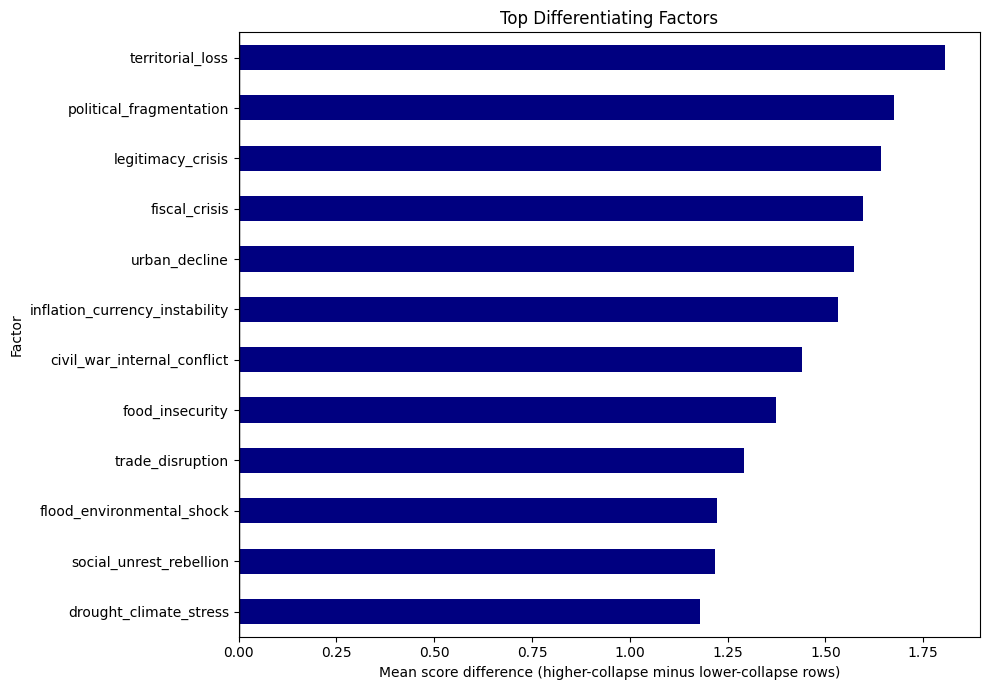

In [3]:
top_differentiating = factor_comparison.head(12)[[
    "category",
    "group_a_mean",
    "group_b_mean",
    "score_difference",
    "group_a_known_n",
    "group_b_known_n",
]].round(3)
display(top_differentiating)

fig, ax = plt.subplots(figsize=(10, 7))
top_differentiating.iloc[::-1]["score_difference"].plot(kind="barh", ax=ax, color="navy")
ax.set_title("Top Differentiating Factors")
ax.set_xlabel("Mean score difference (higher-collapse minus lower-collapse rows)")
ax.set_ylabel("Factor")
ax.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

## Main Factors In Terminal-Collapse Rows

,category,mean_outcome_3,known_n_outcome_3,mean_all_known,known_n_all
political_fragmentation,political,3.000,23,1.468,154
ethnic_sectarian_fragmentation,social,3.000,2,0.645,31
territorial_loss,military_geopolitical,2.913,23,1.213,174
fiscal_crisis,economic,2.737,19,1.297,145
inflation_currency_instability,economic,2.667,3,1.526,19
legitimacy_crisis,political,2.619,21,1.279,147
administrative_overload,political,2.619,21,1.884,147
urban_decline,social,2.609,23,1.138,174
institutional_rigidity,resilience_institutional,2.609,23,1.782,174
military_overstretch,military_geopolitical,2.571,21,1.711,166


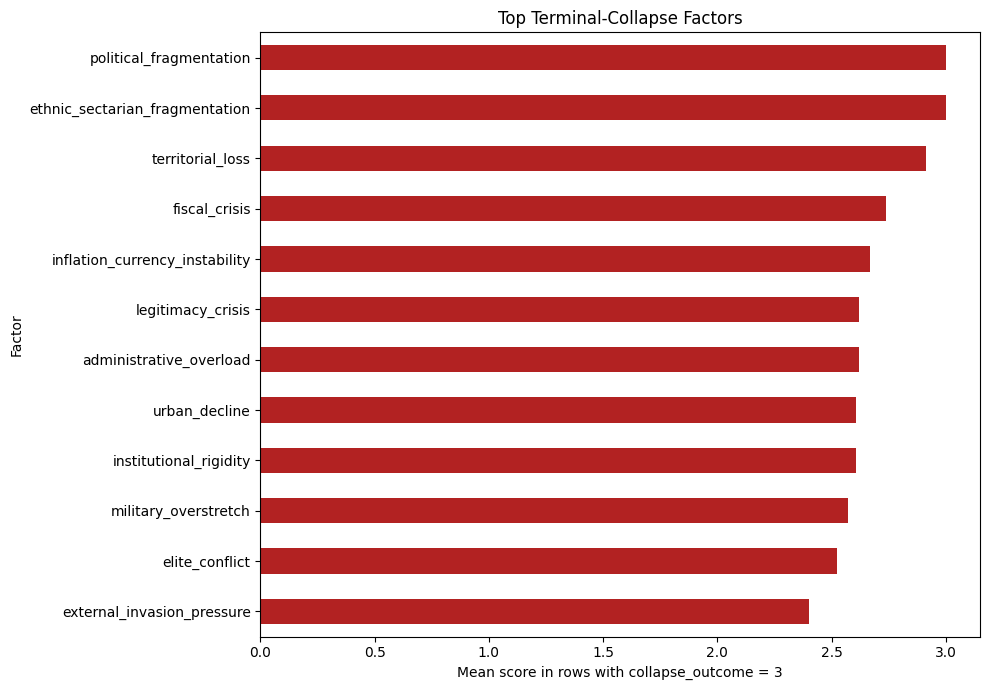

In [4]:
top_terminal = factor_intensity.head(12)[[
    "category",
    "mean_outcome_3",
    "known_n_outcome_3",
    "mean_all_known",
    "known_n_all",
]].round(3)
display(top_terminal)

fig, ax = plt.subplots(figsize=(10, 7))
top_terminal.iloc[::-1]["mean_outcome_3"].plot(kind="barh", ax=ax, color="firebrick")
ax.set_title("Top Terminal-Collapse Factors")
ax.set_xlabel("Mean score in rows with collapse_outcome = 3")
ax.set_ylabel("Factor")
plt.tight_layout()
plt.show()

## Category-Level Findings

In [5]:
display(category_comparison.round(3))

,group_a_mean,group_b_mean,group_a_known_n,group_b_known_n,score_difference
category,,,,,
military_geopolitical,0.855,2.101,359,288,1.246
political,1.049,2.182,386,390,1.133
environmental,0.524,1.625,145,136,1.101
social,0.707,1.741,297,305,1.034
economic,0.974,1.881,390,353,0.907
resilience_institutional,2.138,1.376,456,394,-0.763


## Which Factors Are Well-Supported Across The Dataset

In [6]:
display(well_supported_factors[["category", "known_n", "unknown_prop", "mean_known_score"]].round(3))

,category,known_n,unknown_prop,mean_known_score
recovery_capacity,resilience_institutional,174,0.000,1.983
adaptive_capacity,resilience_institutional,174,0.000,1.914
logistics_food_storage_resilience,resilience_institutional,174,0.000,1.787
institutional_rigidity,resilience_institutional,174,0.000,1.782
territorial_loss,military_geopolitical,174,0.000,1.213
trade_disruption,economic,174,0.000,1.190
urban_decline,social,174,0.000,1.138
food_insecurity,environmental,174,0.000,1.046
resource_dependency,economic,173,0.006,1.861
military_overstretch,military_geopolitical,166,0.046,1.711


## Which Factors Remain Highly Uncertain

,category,known_n,unknown_9_n,unknown_prop,mean_known_score
temperature_anomaly,environmental,13,161,0.925,0.231
flood_environmental_shock,environmental,16,158,0.908,0.688
inflation_currency_instability,economic,19,155,0.891,1.526
ethnic_sectarian_fragmentation,social,31,143,0.822,0.645
ecological_degradation,environmental,36,138,0.793,1.306
demographic_pressure,social,41,133,0.764,1.098
drought_climate_stress,environmental,42,132,0.759,1.286
corruption_governance_failure,political,58,116,0.667,1.983
migration_pressure,social,100,74,0.425,1.240
social_inequality,social,109,65,0.374,1.771


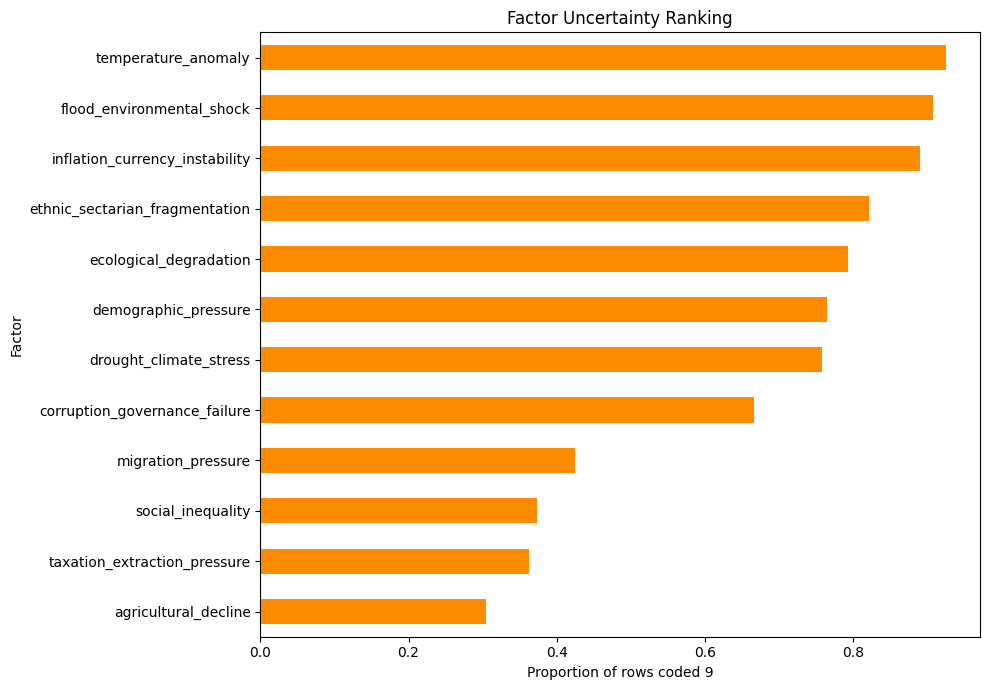

In [7]:
display(high_uncertainty_factors[["category", "known_n", "unknown_9_n", "unknown_prop", "mean_known_score"]].round(3))

fig, ax = plt.subplots(figsize=(10, 7))
high_uncertainty_factors.iloc[::-1]["unknown_prop"].plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Factor Uncertainty Ranking")
ax.set_xlabel("Proportion of rows coded 9")
ax.set_ylabel("Factor")
plt.tight_layout()
plt.show()

## Methodological Limits And Uncertainty

In [8]:
display(highest_uncertainty_cases.round(3))

limits_md = """
### Methodological Limits

- This dataset is a comparative, literature-based coding draft rather than a direct transcription of primary-source evidence.
- Scores reflect historically interpreted intensity, not mechanical measurement.
- Some factors are structurally more uncertain than others because they are harder to infer across archaeological, ancient, and regional cases.
- Modern and well-documented cases often have much denser known-value coverage than ancient or highly debated cases.
- Patterns that remain visible despite missingness and case heterogeneity are more robust than patterns that depend heavily on sparsely known factors.
"""
display(Markdown(limits_md))

,rows,known_factor_values,unknown_9_values,mean_known_factor_score,total_factor_slots,unknown_prop
case_name,,,,,,
Bronze Age Collapse States,8,138,118,1.487,256,0.461
Easter Island,20,346,294,0.991,640,0.459
Maya,14,287,161,1.465,448,0.359
Classic Mesopotamian States,20,425,215,1.566,640,0.336
Inca Empire,7,152,72,1.316,224,0.321
Sassanian Empire,7,156,68,1.448,224,0.304
Aztec Empire,5,115,45,1.393,160,0.281
Western Roman Empire,24,559,209,1.474,768,0.272



### Methodological Limits

- This dataset is a comparative, literature-based coding draft rather than a direct transcription of primary-source evidence.
- Scores reflect historically interpreted intensity, not mechanical measurement.
- Some factors are structurally more uncertain than others because they are harder to infer across archaeological, ancient, and regional cases.
- Modern and well-documented cases often have much denser known-value coverage than ancient or highly debated cases.
- Patterns that remain visible despite missingness and case heterogeneity are more robust than patterns that depend heavily on sparsely known factors.


## Core Findings

This section is written in concise academic language so it can be reused in a README, report, or thesis-style draft.

In [9]:
top_diff_names = ", ".join(top_differentiating.index[:5].tolist())
top_terminal_names = ", ".join(top_terminal.index[:5].tolist())
top_uncertain_names = ", ".join(high_uncertainty_factors.index[:5].tolist())
top_supported_names = ", ".join(well_supported_factors.index[:5].tolist())
top_category_names = ", ".join(category_comparison.head(3).index.tolist())

core_findings_md = f"""
### Core Findings

Across the current first-pass historical collapse dataset, higher-collapse rows are most clearly distinguished by stronger scores in **{top_diff_names}**. These factors separate lower- and higher-collapse rows more strongly than many environmental or demographic variables and are supported by comparatively broad known-value coverage.

Within terminal-collapse rows specifically, the highest-intensity factors are **{top_terminal_names}**. This pattern suggests that terminal breakdown is most consistently associated with fragmentation, territorial erosion, fiscal crisis, and intense political-military disruption rather than with any single monocausal explanation.

At the category level, the clearest separation between lower- and higher-collapse rows appears in **{top_category_names}**. This supports a comparative reading in which collapse is most often expressed through interacting political, military-geopolitical, and broader systemic stress rather than through purely environmental change alone.

The best-supported factors across the dataset, judged by broad known-value coverage, include **{top_supported_names}**. By contrast, the most uncertain factors remain **{top_uncertain_names}**, which are often difficult to code consistently across ancient, archaeological, or highly heterogeneous cases.

Overall, the current dataset supports cautious comparative claims about recurring fragility patterns, but stronger inferences should rely most heavily on patterns that remain visible despite uncertainty, uneven evidence, and case heterogeneity.
"""
display(Markdown(core_findings_md))


### Core Findings

Across the current first-pass historical collapse dataset, higher-collapse rows are most clearly distinguished by stronger scores in **territorial_loss, political_fragmentation, legitimacy_crisis, fiscal_crisis, urban_decline**. These factors separate lower- and higher-collapse rows more strongly than many environmental or demographic variables and are supported by comparatively broad known-value coverage.

Within terminal-collapse rows specifically, the highest-intensity factors are **political_fragmentation, ethnic_sectarian_fragmentation, territorial_loss, fiscal_crisis, inflation_currency_instability**. This pattern suggests that terminal breakdown is most consistently associated with fragmentation, territorial erosion, fiscal crisis, and intense political-military disruption rather than with any single monocausal explanation.

At the category level, the clearest separation between lower- and higher-collapse rows appears in **military_geopolitical, political, environmental**. This supports a comparative reading in which collapse is most often expressed through interacting political, military-geopolitical, and broader systemic stress rather than through purely environmental change alone.

The best-supported factors across the dataset, judged by broad known-value coverage, include **recovery_capacity, adaptive_capacity, logistics_food_storage_resilience, institutional_rigidity, territorial_loss**. By contrast, the most uncertain factors remain **temperature_anomaly, flood_environmental_shock, inflation_currency_instability, ethnic_sectarian_fragmentation, ecological_degradation**, which are often difficult to code consistently across ancient, archaeological, or highly heterogeneous cases.

Overall, the current dataset supports cautious comparative claims about recurring fragility patterns, but stronger inferences should rely most heavily on patterns that remain visible despite uncertainty, uneven evidence, and case heterogeneity.


## What This Dataset Can And Cannot Support

This section keeps the interpretation boundaries explicit so the project can be presented cautiously and transparently.


In [10]:
support_md = """
### What This Dataset Can and Cannot Support

**What it can support**

- Comparative analysis of recurring collapse-related stress patterns across many historical cases.
- Category-level interpretation of political, military, economic, social, environmental, and resilience dynamics.
- Uncertainty-aware exploratory analysis, clustering, and cautious downstream modeling.

**What it cannot support**

- Strong causal claims from single factors alone.
- Fine-grained historical judgments that override specialist case scholarship.
- Sensational predictions about present or future collapse based on direct historical analogy.
- Overconfident interpretation of sparsely known factors or highly uncertain cases.
"""
display(Markdown(support_md))


### What This Dataset Can and Cannot Support

**What it can support**

- Comparative analysis of recurring collapse-related stress patterns across many historical cases.
- Category-level interpretation of political, military, economic, social, environmental, and resilience dynamics.
- Uncertainty-aware exploratory analysis, clustering, and cautious downstream modeling.

**What it cannot support**

- Strong causal claims from single factors alone.
- Fine-grained historical judgments that override specialist case scholarship.
- Sensational predictions about present or future collapse based on direct historical analogy.
- Overconfident interpretation of sparsely known factors or highly uncertain cases.
